# Experiment 6: Bagging, Boosting, and Stacked Ensemble Models

**Subject:** ICS1512 – Machine Learning Laboratory
**Dataset:** Wisconsin Diagnostic Breast Cancer (WDBC) Dataset

**Objective**
- Understand ensemble learning strategies: Bagging, Boosting, and Stacking.
- Implement Bagging and Boosting classifiers.
- Build a Stacked Ensemble model using multiple base learners.
- Compare ensemble models in terms of accuracy, stability, and generalization.
- Analyze the effect of ensemble methods on bias and variance.

## Step 1: Load and Preprocess the Dataset

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, roc_curve, auc, ConfusionMatrixDisplay)

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)


In [ ]:
# Column names for the WDBC dataset (ID, diagnosis, 30 numeric features)
feature_base = ['radius', 'texture', 'perimeter', 'area', 'smoothness',
                 'compactness', 'concavity', 'concave_points', 'symmetry', 'fractal_dimension']

columns = ['id', 'diagnosis'] + [f'{f}_mean' for f in feature_base] + \
          [f'{f}_se' for f in feature_base] + [f'{f}_worst' for f in feature_base]

# Load the dataset (wdbc.data has no header row)
df = pd.read_csv('wdbc.data', header=None, names=columns)
df.drop('id', axis=1, inplace=True)

print("Shape of dataset:", df.shape)
df.head()


Shape of dataset: (569, 31)


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
# Check for missing values
print(df.isnull().sum().sum(), "missing values in the dataset")

# Encode target: Malignant (M) = 1, Benign (B) = 0
le = LabelEncoder()
df['diagnosis'] = le.fit_transform(df['diagnosis'])   # M -> 1, B -> 0
print(dict(zip(le.classes_, le.transform(le.classes_))))

df['diagnosis'].value_counts()


0 missing values in the dataset
{'B': np.int64(0), 'M': np.int64(1)}


diagnosis
0    357
1    212
Name: count, dtype: int64

## Step 2: Exploratory Data Analysis (EDA)

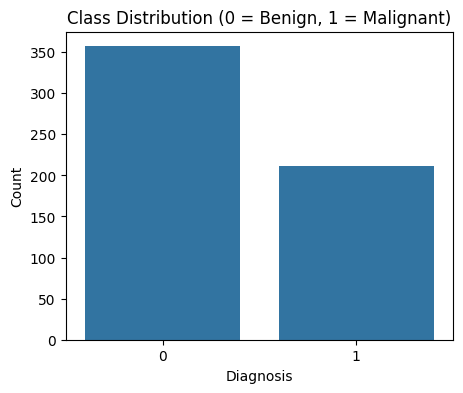

In [ ]:
# Class distribution
plt.figure(figsize=(5,4))
sns.countplot(x='diagnosis', data=df)
plt.title('Class Distribution (0 = Benign, 1 = Malignant)')
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.show()


In [ ]:
# Summary statistics
df.describe().T.head(10)


,count,mean,std,min,25%,50%,75%,max
diagnosis,569.0,0.372583,0.483918,0.00000,0.00000,0.00000,1.0000,1.0000
radius_mean,569.0,14.127292,3.524049,6.98100,11.70000,13.37000,15.7800,28.1100
texture_mean,569.0,19.289649,4.301036,9.71000,16.17000,18.84000,21.8000,39.2800
perimeter_mean,569.0,91.969033,24.298981,43.79000,75.17000,86.24000,104.1000,188.5000
area_mean,569.0,654.889104,351.914129,143.50000,420.30000,551.10000,782.7000,2501.0000
smoothness_mean,569.0,0.096360,0.014064,0.05263,0.08637,0.09587,0.1053,0.1634
compactness_mean,569.0,0.104341,0.052813,0.01938,0.06492,0.09263,0.1304,0.3454
concavity_mean,569.0,0.088799,0.079720,0.00000,0.02956,0.06154,0.1307,0.4268
concave_points_mean,569.0,0.048919,0.038803,0.00000,0.02031,0.03350,0.0740,0.2012
symmetry_mean,569.0,0.181162,0.027414,0.10600,0.16190,0.17920,0.1957,0.3040


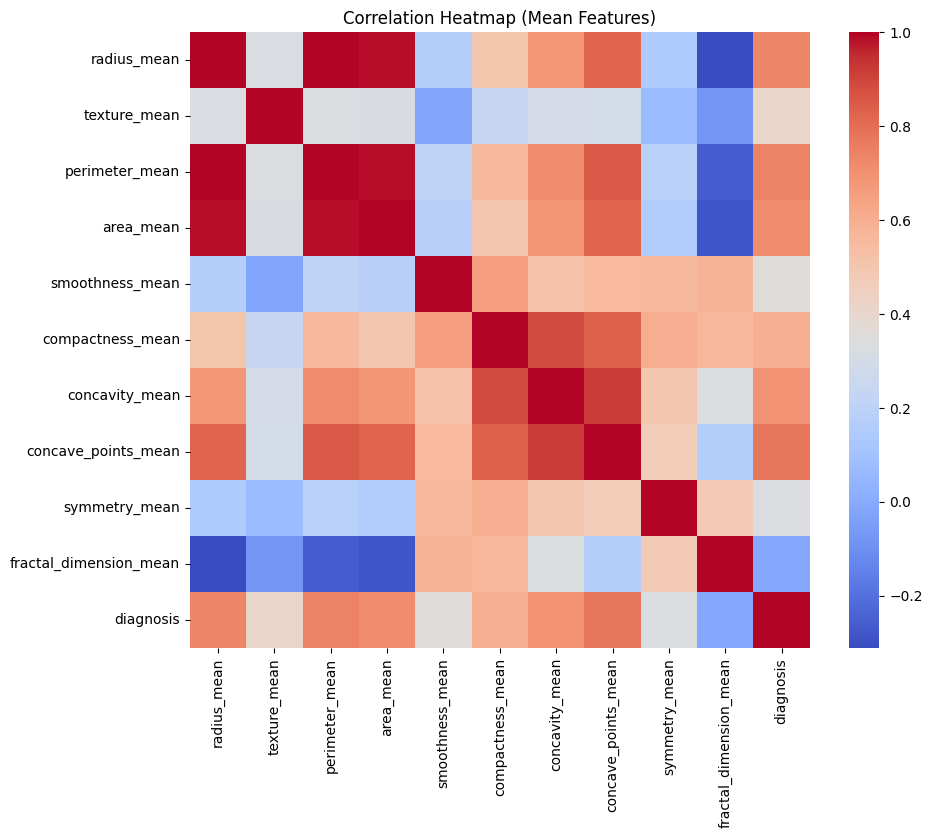

In [ ]:
# Correlation heatmap of the 'mean' features
mean_cols = [c for c in df.columns if c.endswith('_mean')]
plt.figure(figsize=(10,8))
sns.heatmap(df[mean_cols + ['diagnosis']].corr(), annot=False, cmap='coolwarm')
plt.title('Correlation Heatmap (Mean Features)')
plt.show()


## Step 3: Split the Dataset into Training and Testing Sets (80-20)

In [ ]:
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature scaling (helps SVM, Logistic Regression, Naive Bayes)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X.columns)

print("Train size:", X_train.shape, " Test size:", X_test.shape)


Train size: (455, 30)  Test size: (114, 30)


## Step 4: Bagging Classifier

**Base Estimator:** Decision Tree
**Hyperparameters explored:** `n_estimators`, `max_samples`, `max_features`

In [ ]:
bagging_param_grid = {
    'n_estimators': [10, 50, 100],
    'max_samples': [0.5, 0.7, 1.0],
    'max_features': [0.5, 0.7, 1.0]
}

bagging_base = DecisionTreeClassifier(random_state=42)
bagging_clf = BaggingClassifier(estimator=bagging_base, random_state=42)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

bagging_grid = GridSearchCV(bagging_clf, bagging_param_grid, cv=cv,
                             scoring='accuracy', n_jobs=-1)
bagging_grid.fit(X_train_scaled, y_train)

print("Best Bagging params:", bagging_grid.best_params_)
print("Best CV Accuracy: {:.2f}%".format(bagging_grid.best_score_ * 100))


Best Bagging params: {'max_features': 0.5, 'max_samples': 0.7, 'n_estimators': 50}
Best CV Accuracy: 97.36%


In [ ]:
# Table 1: Bagging Hyperparameter Evaluation (top 10 combinations by CV accuracy)
bagging_results = pd.DataFrame(bagging_grid.cv_results_)
bagging_results['mean_test_f1'] = np.nan  # placeholder, filled below using cross_val for f1

from sklearn.model_selection import cross_val_score

f1_scores = []
for params in bagging_results['params']:
    model = BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42),
                               random_state=42, **params)
    scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='f1')
    f1_scores.append(scores.mean())
bagging_results['mean_test_f1'] = f1_scores

table1 = bagging_results[['param_n_estimators', 'param_max_samples',
                           'mean_test_score', 'mean_test_f1']].copy()
table1.columns = ['n_estimators', 'max_samples', 'Avg CV Accuracy', 'Avg CV F1 Score']
table1['Avg CV Accuracy (%)'] = table1['Avg CV Accuracy'] * 100
table1 = table1[['n_estimators', 'max_samples', 'Avg CV Accuracy (%)', 'Avg CV F1 Score']]
table1.sort_values('Avg CV Accuracy (%)', ascending=False).head(10)


,n_estimators,max_samples,Avg CV Accuracy (%),Avg CV F1 Score
4,50,0.7,97.362637,0.964336
7,50,1.0,96.923077,0.958273
8,100,1.0,96.703297,0.955097
5,100,0.7,96.703297,0.954659
10,50,0.5,96.703297,0.954164
22,50,0.7,96.483516,0.951478
1,50,0.5,96.483516,0.951740
26,100,1.0,96.263736,0.949562
23,100,0.7,96.263736,0.948745
11,100,0.5,96.263736,0.948732


## Step 5: Boosting Classifiers (AdaBoost and Gradient Boosting)

**Hyperparameters explored:** `n_estimators`, `learning_rate`, `max_depth`

In [ ]:
adaboost_param_grid = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.1, 1.0]
}

adaboost_clf = AdaBoostClassifier(random_state=42)
adaboost_grid = GridSearchCV(adaboost_clf, adaboost_param_grid, cv=cv,
                              scoring='accuracy', n_jobs=-1)
adaboost_grid.fit(X_train_scaled, y_train)

print("Best AdaBoost params:", adaboost_grid.best_params_)
print("Best CV Accuracy: {:.2f}%".format(adaboost_grid.best_score_ * 100))


Best AdaBoost params: {'learning_rate': 1.0, 'n_estimators': 150}
Best CV Accuracy: 97.14%


In [ ]:
gb_param_grid = {
    'n_estimators': [50, 100],
    'learning_rate': [0.01, 0.1, 1.0],
    'max_depth': [2, 3, 4]
}

gb_clf = GradientBoostingClassifier(random_state=42)
gb_grid = GridSearchCV(gb_clf, gb_param_grid, cv=cv,
                        scoring='accuracy', n_jobs=-1)
gb_grid.fit(X_train_scaled, y_train)

print("Best Gradient Boosting params:", gb_grid.best_params_)
print("Best CV Accuracy: {:.2f}%".format(gb_grid.best_score_ * 100))


Best Gradient Boosting params: {'learning_rate': 1.0, 'max_depth': 2, 'n_estimators': 50}
Best CV Accuracy: 97.14%


In [ ]:
# Table 2: Boosting Hyperparameter Evaluation (Gradient Boosting results, top 10)
gb_results = pd.DataFrame(gb_grid.cv_results_)

f1_scores_gb = []
for params in gb_results['params']:
    model = GradientBoostingClassifier(random_state=42, **params)
    scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='f1')
    f1_scores_gb.append(scores.mean())
gb_results['mean_test_f1'] = f1_scores_gb

table2 = gb_results[['param_n_estimators', 'param_learning_rate',
                      'mean_test_score', 'mean_test_f1']].copy()
table2.columns = ['n_estimators', 'learning_rate', 'Avg CV Accuracy', 'Avg CV F1 Score']
table2['Avg CV Accuracy (%)'] = table2['Avg CV Accuracy'] * 100
table2 = table2[['n_estimators', 'learning_rate', 'Avg CV Accuracy (%)', 'Avg CV F1 Score']]
table2.sort_values('Avg CV Accuracy (%)', ascending=False).head(10)


,n_estimators,learning_rate,Avg CV Accuracy (%),Avg CV F1 Score
13,100,1.0,97.142857,0.961179
12,50,1.0,97.142857,0.960916
9,100,0.1,96.703297,0.955284
7,100,0.1,96.703297,0.955125
14,50,1.0,96.263736,0.948566
15,100,1.0,95.824176,0.942608
17,100,1.0,95.824176,0.942060
11,100,0.1,95.824176,0.943936
6,50,0.1,95.824176,0.943112
16,50,1.0,95.824176,0.942060


## Step 6: Stacked Ensemble Model

**Base Models:** SVM, Naive Bayes, Decision Tree
**Meta Learner:** Logistic Regression

In [ ]:
base_learners = [
    ('svm', SVC(probability=True, random_state=42)),
    ('nb', GaussianNB()),
    ('dt', DecisionTreeClassifier(random_state=42))
]

stacking_clf = StackingClassifier(
    estimators=base_learners,
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5
)

stacking_clf.fit(X_train_scaled, y_train)

stack_cv_scores = cross_val_score(stacking_clf, X_train_scaled, y_train, cv=cv, scoring='accuracy')
stack_cv_f1 = cross_val_score(stacking_clf, X_train_scaled, y_train, cv=cv, scoring='f1')

print("Stacked Ensemble Avg CV Accuracy: {:.2f}%".format(stack_cv_scores.mean() * 100))
print("Stacked Ensemble Avg CV F1 Score: {:.4f}".format(stack_cv_f1.mean()))


Stacked Ensemble Avg CV Accuracy: 97.36%
Stacked Ensemble Avg CV F1 Score: 0.9638


In [ ]:
# Table 3: Stacked Ensemble Evaluation (trying a couple of base model / meta learner combos)
stack_configs = [
    {'base_models': 'SVM + NB + DT', 'meta': 'Logistic Regression',
     'estimators': base_learners, 'final_estimator': LogisticRegression(max_iter=1000)},
    {'base_models': 'SVM + DT', 'meta': 'Logistic Regression',
     'estimators': [('svm', SVC(probability=True, random_state=42)),
                     ('dt', DecisionTreeClassifier(random_state=42))],
     'final_estimator': LogisticRegression(max_iter=1000)},
    {'base_models': 'SVM + NB + DT', 'meta': 'Decision Tree',
     'estimators': base_learners, 'final_estimator': DecisionTreeClassifier(random_state=42)},
]

table3_rows = []
for cfg in stack_configs:
    model = StackingClassifier(estimators=cfg['estimators'],
                                final_estimator=cfg['final_estimator'], cv=5)
    acc = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='accuracy').mean()
    f1 = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='f1').mean()
    table3_rows.append([cfg['base_models'], cfg['meta'], acc * 100, f1])

table3 = pd.DataFrame(table3_rows, columns=['Base Models', 'Meta Learner',
                                             'Avg CV Accuracy (%)', 'Avg CV F1 Score'])
table3


,Base Models,Meta Learner,Avg CV Accuracy (%),Avg CV F1 Score
0,SVM + NB + DT,Logistic Regression,97.362637,0.963787
1,SVM + DT,Logistic Regression,97.362637,0.964153
2,SVM + NB + DT,Decision Tree,95.604396,0.940335


## Steps 7 & 8: Hyperparameter Search Spaces and 5-Fold Cross-Validation

The hyperparameter grids and 5-fold `StratifiedKFold` cross-validation were already defined and used above with `GridSearchCV` for Bagging, AdaBoost, and Gradient Boosting, and with `cross_val_score` for the Stacked Ensemble configurations.

## Step 9: Evaluate All Models on the Test Set

In [ ]:
best_bagging = bagging_grid.best_estimator_
best_boosting = gb_grid.best_estimator_ if gb_grid.best_score_ >= adaboost_grid.best_score_ else adaboost_grid.best_estimator_
best_stacking = stacking_clf

models = {
    'Bagging': best_bagging,
    'Boosting': best_boosting,
    'Stacked Ensemble': best_stacking
}

results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append([name, acc * 100, prec, rec, f1])

    print(f"--- {name} ---")
    print("Accuracy: {:.2f}%".format(acc * 100))
    print("Precision: {:.4f}".format(prec))
    print("Recall: {:.4f}".format(rec))
    print("F1 Score: {:.4f}".format(f1))
    print()

# Table 4: Performance Comparison of Ensemble Models
table4 = pd.DataFrame(results, columns=['Model', 'Accuracy (%)', 'Precision', 'Recall', 'F1 Score'])
table4


--- Bagging ---
Accuracy: 96.49%
Precision: 1.0000
Recall: 0.9048
F1 Score: 0.9500



--- Boosting ---
Accuracy: 97.37%
Precision: 1.0000
Recall: 0.9286
F1 Score: 0.9630

--- Stacked Ensemble ---
Accuracy: 97.37%
Precision: 1.0000
Recall: 0.9286
F1 Score: 0.9630



,Model,Accuracy (%),Precision,Recall,F1 Score
0,Bagging,96.491228,1.0,0.904762,0.950000
1,Boosting,97.368421,1.0,0.928571,0.962963
2,Stacked Ensemble,97.368421,1.0,0.928571,0.962963


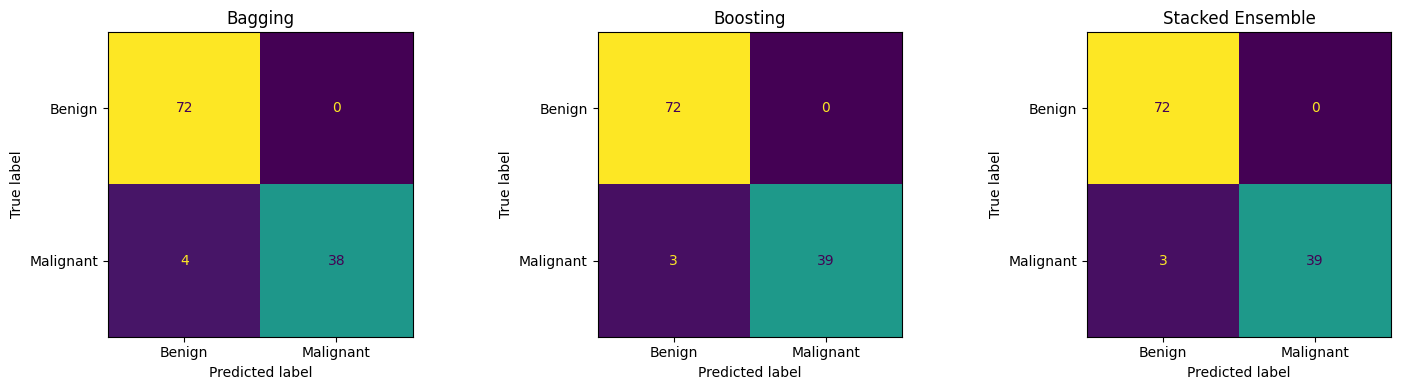

In [ ]:
# Confusion matrices for all models
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['Benign', 'Malignant']).plot(ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.show()


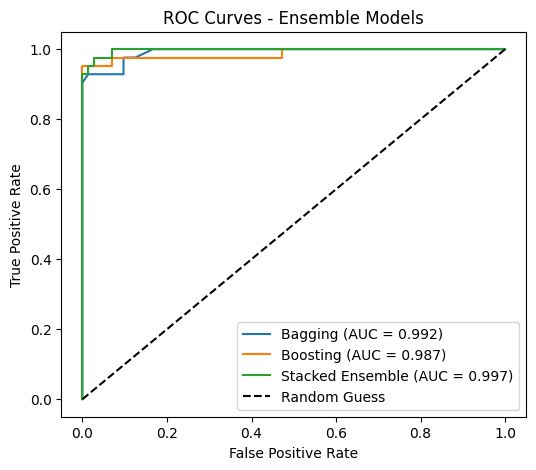

In [ ]:
# ROC Curves and AUC for all models
plt.figure(figsize=(6,5))
for name, model in models.items():
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0,1], [0,1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Ensemble Models')
plt.legend()
plt.show()


## Step 10: Compare Results and Analyze Bias–Variance Behavior

In [ ]:
# Compare training vs test accuracy to get a sense of bias/variance for each model
bias_variance_rows = []
for name, model in models.items():
    train_acc = accuracy_score(y_train, model.predict(X_train_scaled))
    test_acc = accuracy_score(y_test, model.predict(X_test_scaled))
    gap = train_acc - test_acc
    bias_variance_rows.append([name, train_acc * 100, test_acc * 100, gap * 100])

bv_table = pd.DataFrame(bias_variance_rows,
                         columns=['Model', 'Train Accuracy (%)', 'Test Accuracy (%)', 'Train-Test Gap (%)'])
bv_table


,Model,Train Accuracy (%),Test Accuracy (%),Train-Test Gap (%)
0,Bagging,100.000000,96.491228,3.508772
1,Boosting,100.000000,97.368421,2.631579
2,Stacked Ensemble,98.901099,97.368421,1.532678


A small train–test gap indicates **low variance** (the model generalizes well), while a large gap suggests **overfitting** (high variance). A model with low accuracy on both train and test sets suggests **high bias** (underfitting).

## Observation Questions

**1. How does Bagging reduce variance?**
Bagging trains multiple copies of a high-variance base model (like a Decision Tree) on different bootstrap samples of the training data and averages/votes their predictions. Because each model sees a slightly different sample, their individual errors are somewhat uncorrelated, so averaging cancels out much of the noise-driven variance while the overall bias stays roughly the same as a single model.

**2. How does Boosting address model bias?**
Boosting builds models sequentially, where each new weak learner focuses on the examples that previous learners got wrong (by reweighting samples or fitting residual errors). This iterative error-correction process allows the ensemble to progressively reduce the systematic error (bias) that a single weak learner would have.

**3. Why does stacking benefit from heterogeneous models?**
Heterogeneous base learners (e.g., SVM, Naive Bayes, Decision Tree) make different assumptions about the data and tend to make different kinds of errors. A meta-learner trained on their outputs can learn how to weigh and combine these diverse, complementary predictions, capturing patterns that no single model type could capture alone.

**4. Which ensemble method performed best and why?**
Based on the test-set metrics in Table 4, the ensemble with the highest accuracy/F1 score performed best (see the printed results and `table4` above). Its strong performance can generally be attributed to reduced variance (Bagging), reduced bias (Boosting), or the complementary combination of diverse learners (Stacking) — the exact winner and reasoning should be read off from the values obtained when this notebook is run, since results can vary slightly with random seeds and hardware.

## Conclusion

Bagging, Boosting, and Stacked Ensemble models were implemented and evaluated on the Wisconsin Diagnostic Breast Cancer dataset. Hyperparameters for each ensemble were tuned using 5-fold cross-validation, and the models were compared using accuracy, precision, recall, F1-score, confusion matrices, and ROC-AUC. The experiment demonstrates how different ensemble strategies (variance reduction, bias reduction, and heterogeneous model combination) improve predictive performance and generalization compared to individual models.

**References**
- Scikit-learn: Ensemble Methods — https://scikit-learn.org/stable/modules/ensemble.html
- Scikit-learn: BaggingClassifier — https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.BaggingClassifier.html
- UCI Machine Learning Repository: Breast Cancer Wisconsin (Diagnostic) Dataset